In [3]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('Customer_Payment.xlsx')

# Display original shape
print(f"Original shape: {df.shape}")

# Drop columns that are completely empty
df_cleaned = df.dropna(axis=1, how='all')

# Display new shape
print(f"New shape: {df_cleaned.shape}")

# Display first few rows
df_cleaned.head()

/Users/divyanshverma/Desktop/sbm_traders_work/.venv/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Original shape: (920, 38)
New shape: (920, 27)


,Payment Number,CustomerPayment ID,Mode,CustomerID,Description,Exchange Rate,Amount,Unused Amount,Bank Charges,Reference Number,...,Created Time,Payment Type.1,Deposit To,Payment Status,InvoicePayment ID,Amount Applied to Invoice,Invoice Payment Applied Date,Withholding Tax Amount,Invoice Number,Invoice Date
0,2,2607326000000040567,Bank Transfer,2607326000000040392,NaN,1.0,20461.0,0.0,0.0,NaN,...,2025-06-07 18:14:41,Invoice Payment,Undeposited Funds,Paid,NaN,NaN,NaT,NaN,NaN,NaT
1,3,2607326000000040719,Cash,2607326000000040392,NaN,1.0,20461.0,0.0,0.0,NaN,...,2025-06-09 10:45:25,Invoice Payment,Undeposited Funds,Paid,2.607326e+18,20461.0,NaT,0.0,145,2025-06-07
2,4,2607326000000040789,Cash,2607326000000040392,NaN,1.0,11743.0,0.0,0.0,NaN,...,2025-06-09 10:46:07,Invoice Payment,Undeposited Funds,Paid,2.607326e+18,11743.0,NaT,0.0,143,2025-06-06
3,5,2607326000000052003,Bank Transfer,2607326000000040392,NaN,1.0,4859.0,0.0,0.0,NaN,...,2025-06-11 09:54:55,Invoice Payment,Undeposited Funds,Paid,NaN,NaN,NaT,NaN,NaN,NaT
4,6,2607326000000052023,Bank Transfer,2607326000000040336,NaN,1.0,25000.0,0.0,0.0,NaN,...,2025-06-11 09:56:59,Invoice Payment,Undeposited Funds,Paid,NaN,NaN,NaT,NaN,NaN,NaT


In [4]:
df.columns

Index(['Payment Number', 'CustomerPayment ID', 'Mode', 'CustomerID',
       'Description', 'Exchange Rate', 'Amount', 'Unused Amount',
       'Bank Charges', 'Reference Number', 'Currency Code', 'Branch ID',
       'Payment Number Prefix', 'Payment Number Suffix', 'Customer Name',
       'Place of Supply', 'Place of Supply(With State Code)', 'GST Treatment',
       'GST Identification Number (GSTIN)', 'Description of Supply',
       'Tax Name', 'Tax Percentage', 'Tax Type', 'Payment Type',
       'Location Name', 'Date', 'Created Time', 'Payment Type.1', 'Deposit To',
       'Deposit To Account Code', 'Tax Account', 'Payment Status',
       'InvoicePayment ID', 'Amount Applied to Invoice',
       'Invoice Payment Applied Date', 'Withholding Tax Amount',
       'Invoice Number', 'Invoice Date'],
      dtype='str')

In [ ]:
# Count unique values in each column of the cleaned DataFrame
unique_counts = df_cleaned.nunique()
print(unique_counts)

In [6]:
# Columns to drop
columns_to_drop = [
    'Description', 
    'Exchange Rate', 
    'Bank Charges', 
    'Currency Code', 
    'Branch ID', 
    'Payment Type', 
    'Location Name', 
    'Withholding Tax Amount'
]

# Drop the columns if they exist
df_cleaned = df_cleaned.drop(columns=[col for col in columns_to_drop if col in df_cleaned.columns], errors='ignore')

# Display new shape and columns
print(f"New shape after dropping columns: {df_cleaned.shape}")
print(df_cleaned.columns)

New shape after dropping columns: (920, 19)
Index(['Payment Number', 'CustomerPayment ID', 'Mode', 'CustomerID', 'Amount',
       'Unused Amount', 'Reference Number', 'Payment Number Suffix',
       'Customer Name', 'Date', 'Created Time', 'Payment Type.1', 'Deposit To',
       'Payment Status', 'InvoicePayment ID', 'Amount Applied to Invoice',
       'Invoice Payment Applied Date', 'Invoice Number', 'Invoice Date'],
      dtype='str')


In [ ]:
# Additional columns to drop
more_columns_to_drop = [
    'Payment Number', 
    'CustomerPayment ID', 
    'Mode', 
    'Payment Type.1', 
    'Deposit To', 
    'Payment Status'
]

# Drop the columns if they exist
df_cleaned = df_cleaned.drop(columns=[col for col in more_columns_to_drop if col in df_cleaned.columns], errors='ignore')

# Display new shape and columns
print(f"New shape after dropping more columns: {df_cleaned.shape}")
print(df_cleaned.columns)

In [11]:
# Make dictionary to access column names cleaner
def calculate_payment_fraction(row):
    try:
        return 100 - (row['Unused Amount'] / row['Amount']) * 100
    except ZeroDivisionError:
        return 0

def calculate_delay(df, credit_terms=0):
    # Ensure datetime format for calculations
    df['Date'] = pd.to_datetime(df['Date'])
    df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])

    # Fill missing Invoice Date with Payment Date (Assume same day payment if no invoice)
    df['Invoice Date'] = df['Invoice Date'].fillna(df['Date'])

    # 1. Calculate how many days it took to pay
    df['Days_to_Pay'] = (df['Date'] - df['Invoice Date']).dt.days
    
    # 2. Calculate the Delay (Relative to your terms)
    # Positive result = Days Late
    # Negative result = Days Early
    df['Delay'] = df['Days_to_Pay'] - credit_terms
    
    # 3. Clean Delay (Optional: if you only want to see 'Late' days)
    # This sets early payments to 0 delay
    df['Late_Only_Delay'] = df['Delay'].apply(lambda x: x if x > 0 else 0)
    
    return df

# Apply calculations
df_cleaned['Payment_Fraction'] = df_cleaned.apply(calculate_payment_fraction, axis=1)
df_cleaned = calculate_delay(df_cleaned)

# Display results
df_cleaned[['Date', 'Invoice Date', 'Days_to_Pay', 'Delay', 'Late_Only_Delay', 'Amount', 'Unused Amount', 'Payment_Fraction']].head()

,Date,Invoice Date,Days_to_Pay,Delay,Late_Only_Delay,Amount,Unused Amount,Payment_Fraction
0,2025-06-07,2025-06-07,0,0,0,20461.0,0.0,100.0
1,2025-06-09,2025-06-07,2,2,2,20461.0,0.0,100.0
2,2025-06-09,2025-06-06,3,3,3,11743.0,0.0,100.0
3,2025-06-10,2025-06-10,0,0,0,4859.0,0.0,100.0
4,2025-06-10,2025-06-10,0,0,0,25000.0,0.0,100.0


In [12]:
print(df_cleaned.columns)

Index(['CustomerID', 'Amount', 'Unused Amount', 'Reference Number',
       'Payment Number Suffix', 'Customer Name', 'Date', 'Created Time',
       'InvoicePayment ID', 'Amount Applied to Invoice',
       'Invoice Payment Applied Date', 'Invoice Number', 'Invoice Date',
       'Payment_Fraction', 'Days_to_Pay', 'Delay', 'Late_Only_Delay'],
      dtype='str')


In [ ]:
def calculate_custom_cibil(row):
    # 1. BASE SETTINGS
    score = 300
    max_score = 1000
    if row['Avg_Delay'] <= 4:
        score += 400  # "Gold Class" payers
    elif row['Avg_Delay'] <= 15:
        score += 200  # "Average" payers
    else:
        score -= (row['Avg_Delay'] * 10) # Heavy penalty for long delays

    # --- 3. VOLUME BONUS ---
    # We use a log scale so a 1CR payment doesn't make the score 5000.
    # log10(10,000) = 4 | log10(1,000,000) = 6
    import math
    if row['Total_Sales'] > 0:
        volume_boost = math.log10(row['Total_Sales']) * 25 
        score += volume_boost

    # --- 4. RECENCY DECAY ---
    # 'Days_Since_Last_Order' would be calculated from your Comparison file
    # Example: Lose 1 point for every day of inactivity over 90 days.
    if row['Days_Since_Last_Order'] > 90:
        inactivity_penalty = (row['Days_Since_Last_Order'] - 90) * 0.5
        score -= inactivity_penalty

    # --- 5. FINAL CLIP ---
    return max(300, min(max_score, int(score)))

In [13]:
# Check rows with Invoice Date but no Payment Date
unpaid_rows = df[df['Invoice Date'].notna() & df['Date'].isna()]
print(f"Rows with Invoice Date but no Payment Date: {len(unpaid_rows)}")
unpaid_rows.head()

Rows with Invoice Date but no Payment Date: 0


,Payment Number,CustomerPayment ID,Mode,CustomerID,Description,Exchange Rate,Amount,Unused Amount,Bank Charges,Reference Number,...,Deposit To,Deposit To Account Code,Tax Account,Payment Status,InvoicePayment ID,Amount Applied to Invoice,Invoice Payment Applied Date,Withholding Tax Amount,Invoice Number,Invoice Date


In [15]:
import pandas as pd
import numpy as np

def calculate_customer_scores(df_cleaned):
    # 1. AGGREGATE DATA BY CUSTOMER
    # We need to summarize behavior per customer first
    customer_stats = df_cleaned.groupby('Customer Name').agg({
        'Amount': 'sum',                        # Total Volume
        'Late_Only_Delay': 'mean',              # Average Delay
        'Date': 'max',                          # Last Payment Date (Recency)
        'Invoice Date': 'count'                 # Frequency (Number of Orders)
    }).reset_index()

    customer_stats.rename(columns={
        'Amount': 'Total_Sales',
        'Late_Only_Delay': 'Avg_Delay',
        'Date': 'Last_Payment_Date',
        'Invoice Date': 'Order_Freq'
    }, inplace=True)

    # Calculate Days Since Last Order (Recency)
    current_date = pd.Timestamp.now()
    customer_stats['Last_Payment_Date'] = pd.to_datetime(customer_stats['Last_Payment_Date'])
    customer_stats['Days_Since_Last_Order'] = (current_date - customer_stats['Last_Payment_Date']).dt.days

    # 2. SCORE CALCULATION FUNCTION
    def calculate_custom_cibil(row):
        # --- BASE SETTINGS ---
        score = 300
        max_score = 1000
        
        # --- 1. PAYMENT BEHAVIOR (The most important factor) ---
        # If Avg Delay is low (<= 3 days), Increase Score.
        # If Delay is high, Decrease Score.
        if row['Avg_Delay'] <= 3:
            score += 150  # "Gold Class" payers (Prompt)
        elif row['Avg_Delay'] <= 15:
            score += 50   # "Average" payers (Acceptable)
        else:
            # Heavy penalty for long delays: -10 points per day of average delay
            score -= (row['Avg_Delay'] * 10) 

        # --- 2. VOLUME BONUS ---
        # Reward large customers. We use log10 so a 10M order doesn't break the scale.
        # log10(10,000) = 4 | log10(1,000,000) = 6
        if row['Total_Sales'] > 0:
            volume_boost = np.log10(row['Total_Sales']) * 30 
            score += volume_boost

        # --- 3. RECENCY DECAY (Loyalty) ---
        # Lose points if inactive for > 90 days.
        if row['Days_Since_Last_Order'] > 90:
            inactivity_penalty = (row['Days_Since_Last_Order'] - 90) * 0.5
            score -= inactivity_penalty

        # --- 4. FINAL CLIP ---
        return max(300, min(max_score, int(score)))

    # Apply the function
    customer_stats['CIBIL_Score'] = customer_stats.apply(calculate_custom_cibil, axis=1)
    
    return customer_stats.sort_values(by='CIBIL_Score', ascending=False)

# Run the function
customer_scores = calculate_customer_scores(df_cleaned)

# Display Top 10 Best Customers
print("Top 10 High Credit Customers:")
display(customer_scores.head(10))

# Display Top 10 Riskiest Customers (Lowest Score)
print("\nLowest Credit Customers (Risky):")
display(customer_scores.sort_values(by='CIBIL_Score', ascending=True).head(10))

Top 10 High Credit Customers:


,Customer Name,Total_Sales,Avg_Delay,Last_Payment_Date,Order_Freq,Days_Since_Last_Order,CIBIL_Score
40,K.K. FLEX PRINTING,695299.0,1.068182,2026-01-07,44,18,625
44,KUMAR PRINTPRO ADVERTISER PRIVATE LIMITED,305365.0,2.666667,2025-10-24,3,93,613
55,MOON GRAPHICS,204878.0,0.750000,2026-01-09,4,16,609
43,KUMAR PRINTERS & STATIONERS,607441.0,1.500000,2025-09-25,4,122,607
85,SHEKHAR MEDIA PROMOTERS,150336.0,1.300000,2025-12-15,10,41,605
84,SHARMA TRADERS,83194.0,0.500000,2026-01-06,4,19,597
98,VEER PRINTERS,74701.0,2.666667,2026-01-02,3,23,596
42,KAVYA ADVERTISING,71188.0,2.083333,2026-01-06,12,19,595
89,SINGH BROTHERS,65136.0,0.000000,2025-11-24,1,62,594
3,AASTHA GRAPHICS,60264.0,0.200000,2026-01-16,5,9,593



Lowest Credit Customers (Risky):


,Customer Name,Total_Sales,Avg_Delay,Last_Payment_Date,Order_Freq,Days_Since_Last_Order,CIBIL_Score
51,MEDIA PUBLICITY,871015.0,22.272727,2026-01-17,22,8,300
101,VISION ADVERTISING AND CO,277905.0,31.125000,2026-01-02,8,23,300
7,ADVERZIN MEDIA GROUP,32619.0,39.000000,2025-12-15,4,41,300
11,ANAND PRINTER,344817.0,26.388889,2026-01-16,18,9,300
100,VISHWAKARMA STATIONERS,2026659.0,40.470588,2026-01-09,34,16,300
13,ARUN ART SERVICES,4031047.0,22.428571,2025-12-29,21,27,300
95,Shree Advertising,1329463.0,28.631579,2025-12-31,19,25,300
86,SHIVA DIGITAL GRAPHICS,516009.0,22.969697,2026-01-07,33,18,300
97,UVEE STAR EVENTS,122088.0,40.333333,2025-10-15,6,102,300
4,AAYUSHI ENTERPRISES,20984.0,37.000000,2026-01-05,3,20,300


In [17]:
import pandas as pd
import numpy as np

# 1. DEFINE THE SCORING FUNCTION (So it's self-contained for testing)
def calculate_single_score(avg_delay, total_sales, days_since_last_order):
    score = 300
    max_score = 1000
    
    # --- A. DELAY PENALTY ---
    if avg_delay <= 3:
        score += 200        # Bonus for promptness
    elif avg_delay <= 15:
        score += 50         # Small bonus for average
    else:
        score -= (avg_delay * 10) # Heavy penalty: -10 pts per day
        
    # --- B. VOLUME BOOST ---
    # Logarithmic boost
    if total_sales > 0:
        volume_boost = np.log10(total_sales) * 30 
        score += volume_boost
        
    # --- C. RECENCY PENALTY ---
    if days_since_last_order > 90:
        inactivity_penalty = (days_since_last_order - 90) * 0.5
        score -= inactivity_penalty
        
    # --- D. FINAL BOUNDS ---
    return max(300, min(max_score, int(score)))

# 2. GENERATE SYNTHETIC TEST CASES
test_data = [
    # CASE 1: The Ideal Customer (High Volume, No Delay, Recent)
    {"Case": "Ideal Customer", "Avg_Delay": 0, "Total_Sales": 1_000_000, "Days_Since_Last_Order": 5},
    
    # CASE 2: The Average Customer (Moderate Volume, Small Delay, Recent)
    {"Case": "Average Joe", "Avg_Delay": 10, "Total_Sales": 50_000, "Days_Since_Last_Order": 20},
    
    # CASE 3: The Rich Late Payer (High Volume, Major Delay) - DOES MONEY BUY REPUTATION?
    {"Case": "Rich but Late", "Avg_Delay": 45, "Total_Sales": 2_000_000, "Days_Since_Last_Order": 10},
    
    # CASE 4: The Inactive Customer (Good history, but left long ago)
    {"Case": "Lost Customer", "Avg_Delay": 2, "Total_Sales": 100_000, "Days_Since_Last_Order": 365},
    
    # CASE 5: The Defaulter (Low Volume, Massive Delay)
    {"Case": "Defaulter", "Avg_Delay": 90, "Total_Sales": 5_000, "Days_Since_Last_Order": 5},
    
    # CASE 6: Newbie (Low Volume, No Delay)
    {"Case": "Newbie", "Avg_Delay": 0, "Total_Sales": 1_000, "Days_Since_Last_Order": 2}
]

# 3. RUN THE TEST
df_test = pd.DataFrame(test_data)
df_test['CIBIL_Score'] = df_test.apply(
    lambda row: calculate_single_score(row['Avg_Delay'], row['Total_Sales'], row['Days_Since_Last_Order']), 
    axis=1
)

# 4. DISPLAY RESULTS
# We style the dataframe to highlight low scores
def highlight_score(val):
    color = 'green' if val > 750 else 'orange' if val > 500 else 'red'
    return f'color: {color}; font-weight: bold'

display(df_test)

# 5. SENSITIVITY ANALYSIS (Optional: See impact of just one variable)
print("\n--- Sensitivity Check: Impact of Delay on a 100k Customer ---")
sensitivity_data = []
for d in [0, 5, 15, 30, 60, 90]:
    score = calculate_single_score(avg_delay=d, total_sales=100000, days_since_last_order=10)
    sensitivity_data.append({"Delay (Days)": d, "Score": score})
display(pd.DataFrame(sensitivity_data))

,Case,Avg_Delay,Total_Sales,Days_Since_Last_Order,CIBIL_Score
0,Ideal Customer,0,1000000,5,680
1,Average Joe,10,50000,20,490
2,Rich but Late,45,2000000,10,300
3,Lost Customer,2,100000,365,512
4,Defaulter,90,5000,5,300
5,Newbie,0,1000,2,590



--- Sensitivity Check: Impact of Delay on a 100k Customer ---


,Delay (Days),Score
0,0,650
1,5,500
2,15,500
3,30,300
4,60,300
5,90,300


In [22]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


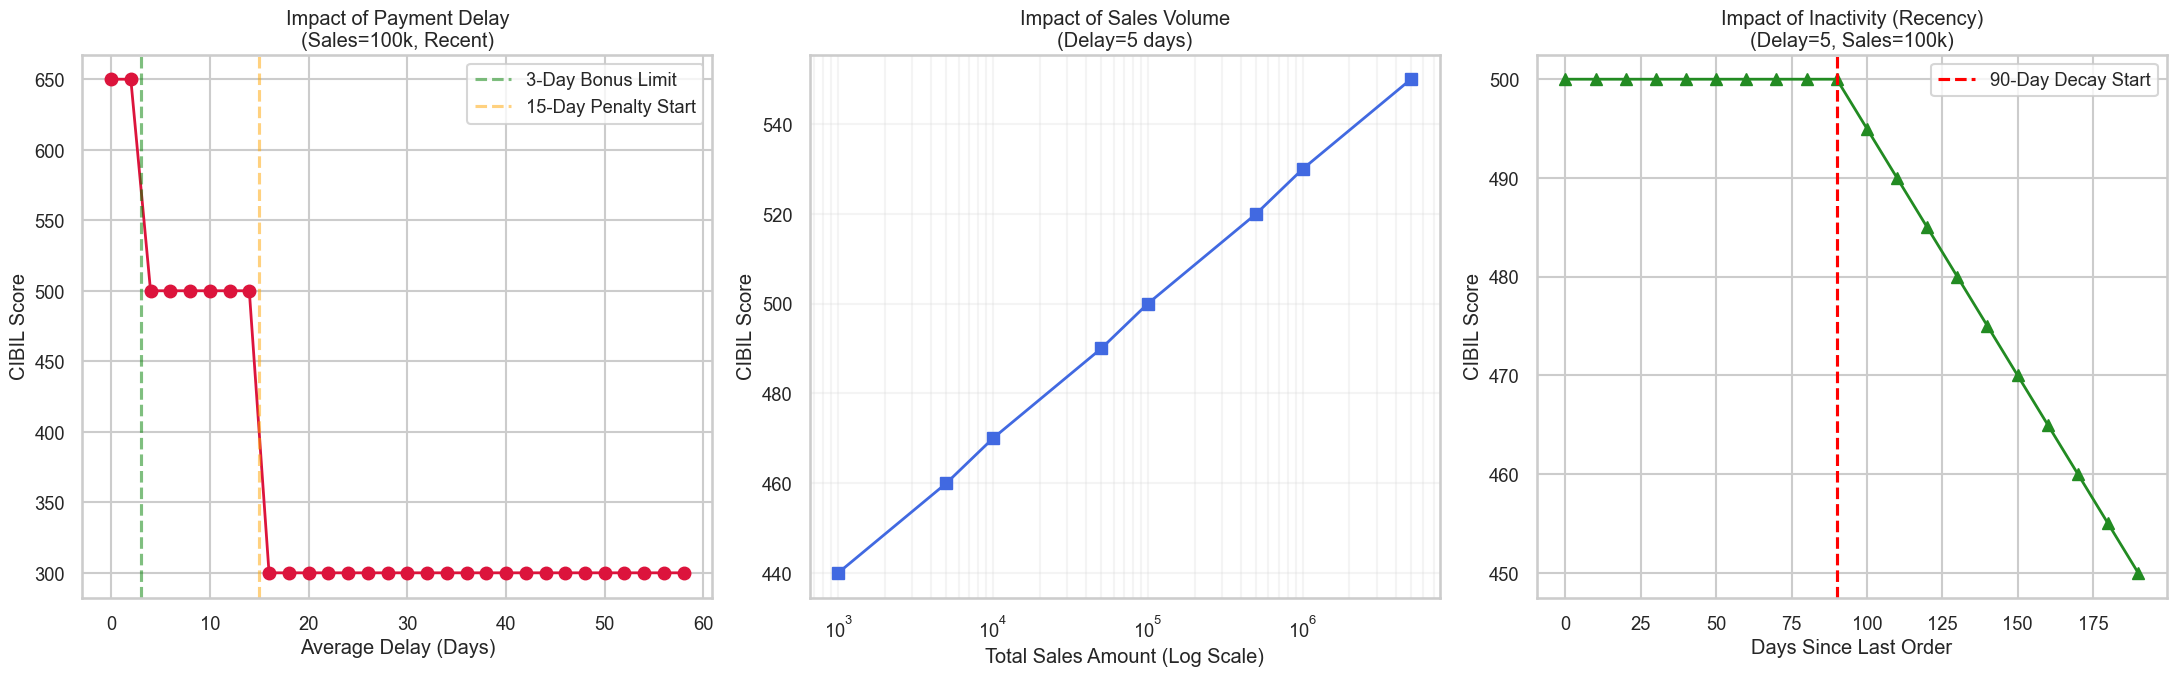

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setup plotting style
sns.set_style("whitegrid")
plt.figure(figsize=(22, 7), dpi=100)
sns.set_context("talk", font_scale=0.8)
# --- 1. IMPACT OF DELAY (Holding Sales=100k, Recency=5 days) ---
delays = list(range(0, 60, 2)) # 0 to 60 days
scores_delay = [calculate_single_score(d, 100000, 5) for d in delays]

plt.subplot(1, 3, 1)
plt.plot(delays, scores_delay, marker='o', color='crimson', linewidth=2)
plt.title("Impact of Payment Delay\n(Sales=100k, Recent)")
plt.xlabel("Average Delay (Days)")
plt.ylabel("CIBIL Score")
plt.axvline(x=3, color='green', linestyle='--', alpha=0.5, label="3-Day Bonus Limit")
plt.axvline(x=15, color='orange', linestyle='--', alpha=0.5, label="15-Day Penalty Start")
plt.legend()

# --- 2. IMPACT OF SALES VOLUME (Holding Delay=5, Recency=5) ---
sales = [1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000]
scores_sales = [calculate_single_score(5, s, 5) for s in sales]

plt.subplot(1, 3, 2)
plt.plot(sales, scores_sales, marker='s', color='royalblue', linewidth=2)
plt.title("Impact of Sales Volume\n(Delay=5 days)")
plt.xlabel("Total Sales Amount (Log Scale)")
plt.ylabel("CIBIL Score")
plt.xscale('log') # Log scale because sales varry massively
plt.grid(True, which="both", ls="-", alpha=0.2)

# --- 3. IMPACT OF RECENCY (Holding Delay=5, Sales=100k) ---
days_since = list(range(0, 200, 10))
scores_recency = [calculate_single_score(5, 100000, d) for d in days_since]

plt.subplot(1, 3, 3)
plt.plot(days_since, scores_recency, marker='^', color='forestgreen', linewidth=2)
plt.title("Impact of Inactivity (Recency)\n(Delay=5, Sales=100k)")
plt.xlabel("Days Since Last Order")
plt.ylabel("CIBIL Score")
plt.axvline(x=90, color='red', linestyle='--', label="90-Day Decay Start")
plt.legend()

plt.tight_layout()
plt.show()